In [1]:
import numpy as np
import cf_xarray # gives the ds.cf and da.cf objects
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from cmocean.tools import crop_by_percent
import gsw
import xgcm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='auto')
client

/opt/tljh/user/lib/python3.7/site-packages/distributed/node.py:155: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36175 instead
  http_address["port"], self.http_server.port


Client Scheduler: tcp://127.0.0.1:45811 Dashboard: http://127.0.0.1:36175/status,Cluster Workers: 4 Cores: 4 Memory: 16.75 GB


# Open data and create grid

In [3]:
from pathlib import Path
datadir = Path('../data/processed/')
datadirraw = Path('../data/raw/interp_monthly/')

In [4]:
def preprocess(ds):
    if 'Z' in ds.variables:
        ds['Z'] = - ds.Z
        ds = ds.rename({'Z':'depth'})
    return ds

ds = xr.open_mfdataset([*datadirraw.glob('**/*.nc'), *datadir.glob('*.nc')], preprocess=preprocess)
ds

<xarray.Dataset>
Dimensions:            (depth_left: 50, i: 720, j: 360, k: 50, nv: 2, time: 252, year: 21)
Coordinates:
    dzc                (depth_left) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    dzt                (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
  * depth_left         (depth_left) float32 0.0 10.0 20.0 ... 5250.25 5683.75
  * k                  (k) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    depth              (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    latitude           (j) float64 dask.array<chunksize=(360,), meta=np.ndarray>
    longitude          (i) float64 dask.array<chunksize=(720,), meta=np.ndarray>
  * i                  (i) int64 0 1 2 3 4 5 6 7 ... 713 714 715 716 717 718 719
  * j                  (j) int64 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * time               (time) datetime64[ns] 1997-01-16T12:00:00 ... 2017-12-16
    timestep           (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds          (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    phi_dep_mld_t      int64 ...
  * year               (year) int64 1997 1998 1999 2000 ... 2014 2015 2016 2017
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH           (time, j, i) float64 dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SALT               (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
    SCI_mean           (year, j, i) float64 dask.array<chunksize=(21, 360, 720), meta=np.ndarray>
    THETA              (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
    alpha_mixed_layer  (j, i) float64 dask.array<chunksize=(360, 720), meta=np.ndarray>
    alpha_surface      (j, i) float64 dask.array<chunksize=(360, 720), meta=np.ndarray>
Attributes:
    product_time_coverage_start:  1992-01-01T12:00:00
    author:                       Ou Wang and Ian Fenty
    Insitution:                   JPL
    product_version:              ECCO Version 4 Release 4
    time_units:                   days since 1992-01-01 00:00:00
    Conventions:                  CF-1.6
    Project:                      Estimating the Circulation and Climate of t...
    cdm_data_type:                Grid
    geospatial_lon_units:         degrees_east
    Metadata_Conventions:         CF-1.6, Unidata Dataset Discovery v1.0, GDS...
    no_data:                      NaNf
    geospatial_lat_units:         degrees_north
    product_time_coverage_end:    2017-12-31T12:00:00
    geospatial_vertical_min:      -5906.25
    nz:                           50
    geospatial_vertical_units:    meter
    geospatial_vertical_max:      -5.0
    date_created:                 Thu Aug 22 18:56:33 2019
    time_coverage_start:          2013-12-01T00:00:00
    time_coverage_end:            2014-01-01T00:00:00

# Plot deepest ML for year 2002

In [5]:
ds = ds.sel(time='2002')

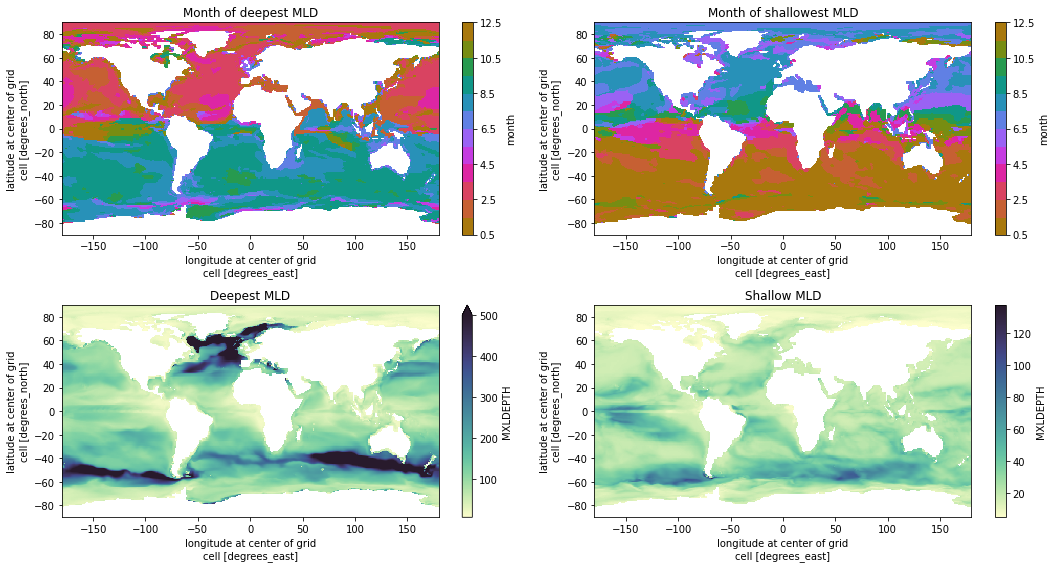

In [6]:
fig, ax = plt.subplots(2,2,figsize=(15,8))

ds.time.dt.month.where(ds.MXLDEPTH == ds.MXLDEPTH.max('time')).mean('time').where(ds.MXLDEPTH.max('time')>0).plot(
    x='longitude', y='latitude',
    ax=ax[0,0],vmin=0.5,vmax=12.5,cmap=cmo.phase, levels=13
)
ax[0,0].set_title('Month of deepest MLD')

ds.MXLDEPTH.max('time').where(ds.MXLDEPTH.max('time')>0).plot(
    x='longitude', y='latitude',
    ax=ax[1,0], vmax=500, cmap=cmo.deep
)
ax[1,0].set_title('Deepest MLD')


ds.time.dt.month.where(ds.MXLDEPTH == ds.MXLDEPTH.min('time')).mean('time').where(ds.MXLDEPTH.max('time')>0).plot(
    x='longitude', y='latitude',
    ax=ax[0,1],vmin=0.5,vmax=12.5,cmap=cmo.phase, levels=13
)
ax[0,1].set_title('Month of shallowest MLD')

ds.MXLDEPTH.min('time').where(ds.MXLDEPTH.max('time')>0).plot(
    x='longitude', y='latitude',
    ax=ax[1,1], cmap=cmo.deep
)
ax[1,1].set_title('Shallow MLD')

plt.tight_layout()

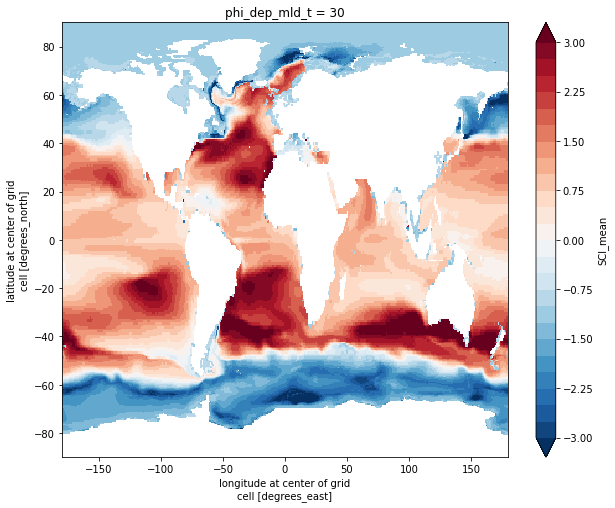

In [7]:
ds.SCI_mean.mean('year').plot(x='longitude', y='latitude', cmap='RdBu_r', levels=np.linspace(-3,3,25), figsize=(10,8))

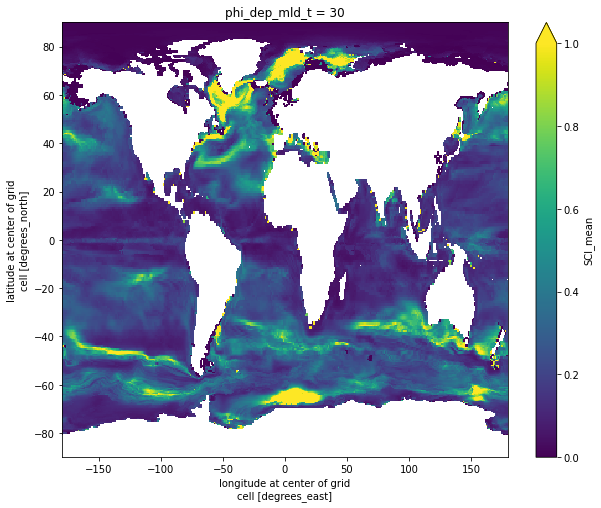

In [8]:
ds.SCI_mean.std('year').plot(x='longitude', y='latitude', figsize=(10,8), vmax=1)